In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
import subprocess

matplotlib.rcParams.update({"axes.grid": True})
# matplotlib.rcParams.keys()

In [11]:
compile = subprocess.run(
    ["./compile_project"],
    capture_output=True,
    text=True
)

print(compile.stdout)
print(compile.stderr)

-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/davide/GitHub/computational_physics_2_2026/variational-monte-carlo-fys4411-DC2026/build
[  4%] Linking CXX executable vmc
[100%] Built target vmc

mkdir: cannot create directory ‘build’: File exists



In [12]:
# result = subprocess.run(
#     ["./vmc", "true"],
#     capture_output=True,
#     text=True
# )

# print(result.stdout)
# print(result.stderr)

Text(0.5, 0, '$\\alpha$')

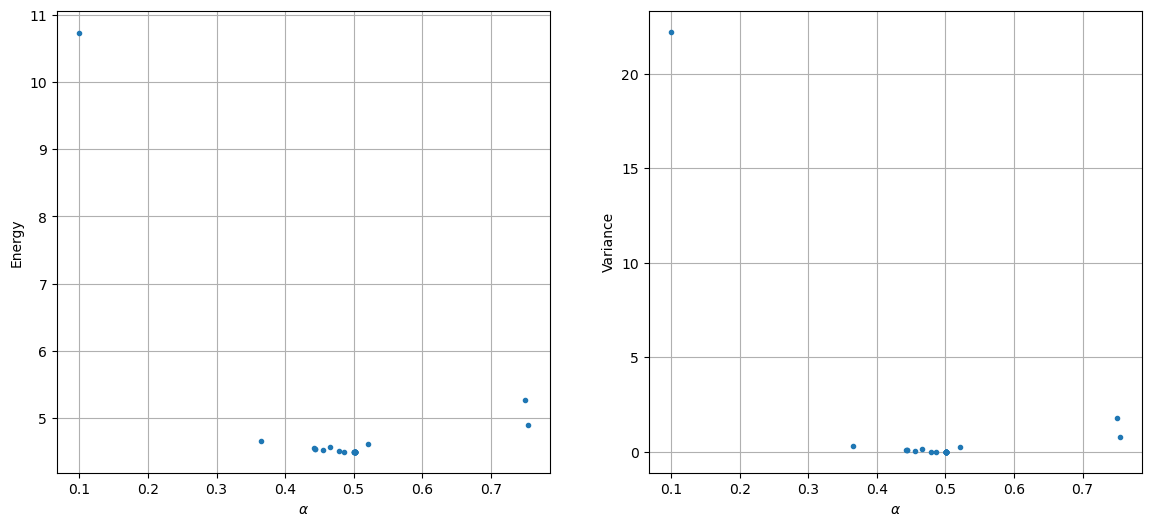

In [13]:
%matplotlib inline

file = np.loadtxt("iofiles/log.csv", delimiter=',')
file = np.transpose(file)
parameters = file[:file.shape[0] - 5, :]
energy = file[file.shape[0] - 5, :]
variance = file[file.shape[0] - 4, :]
error = file[file.shape[0] - 3, :]

fig = plt.figure(figsize=(14,6))
gs = fig.add_gridspec(1,2)
ax = fig.add_subplot(gs[0, 0])
ax.errorbar(parameters[0, :], energy, error, ls="none", marker='.')
ax.set_ylabel("Energy")
ax.set_xlabel(r"$\alpha$")
ax = fig.add_subplot(gs[0, 1])
ax.errorbar(parameters[0, :], variance, ls="none", marker='.')
ax.set_ylabel("Variance")
ax.set_xlabel(r"$\alpha$")

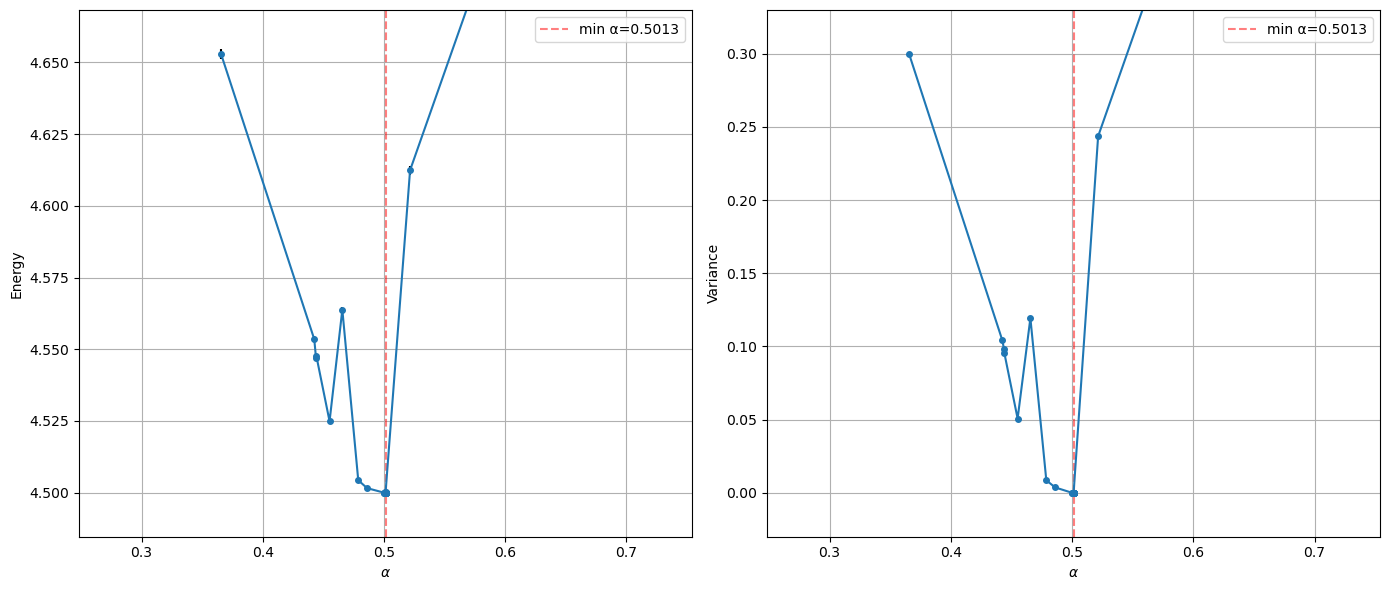

In [14]:
%matplotlib inline

file = np.loadtxt("iofiles/log.csv", delimiter=',')
file = np.transpose(file)
parameters = file[:file.shape[0] - 5, :]
energy = file[file.shape[0] - 5, :]
variance = file[file.shape[0] - 4, :]
error = file[file.shape[0] - 3, :]

# Skip first few iterations
burnin = 2
parameters = parameters[:, burnin:]
energy = energy[burnin:]
variance = variance[burnin:]
error = error[burnin:]

# Sort by alpha
sort_idx = np.argsort(parameters[0, :])
parameters = parameters[:, sort_idx]
energy = energy[sort_idx]
variance = variance[sort_idx]
error = error[sort_idx]

# Find minimum and compute symmetric window around it
min_idx = np.argmin(energy)
min_alpha = parameters[0, min_idx]
max_dist = np.max(np.abs(parameters[0, :] - min_alpha))

# Mask for points within the x window, excluding boundary point
mask = np.abs(parameters[0, :] - min_alpha) < 0.99 * max_dist

fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 2)

ax = fig.add_subplot(gs[0, 0])
ax.errorbar(parameters[0, :], energy, error, ls='-', marker='.', markersize=8, ecolor='black')
ax.axvline(min_alpha, color='red', linestyle='--', alpha=0.5, label=f"min α={min_alpha:.4f}")
ax.set_xlim(min_alpha - max_dist, min_alpha + max_dist)
e_min, e_max = np.min(energy[mask]), np.max(energy[mask])
e_range = e_max - e_min
ax.set_ylim(e_min - 0.1 * e_range, e_max + 0.1 * e_range)
ax.set_ylabel("Energy")
ax.set_xlabel(r"$\alpha$")
ax.legend()

ax = fig.add_subplot(gs[0, 1])
ax.errorbar(parameters[0, :], variance, ls='-', marker='.', markersize=8, ecolor='black')
ax.axvline(min_alpha, color='red', linestyle='--', alpha=0.5, label=f"min α={min_alpha:.4f}")
ax.set_xlim(min_alpha - max_dist, min_alpha + max_dist)
v_min, v_max = np.min(variance[mask]), np.max(variance[mask])
v_range = v_max - v_min
ax.set_ylim(v_min - 0.1 * v_range, v_max + 0.1 * v_range)
ax.set_ylabel("Variance")
ax.set_xlabel(r"$\alpha$")
ax.legend()

plt.tight_layout()
plt.show()

In [19]:
%matplotlib auto

file = np.loadtxt("iofiles/log.csv", delimiter=',')
file = np.transpose(file)
parameters = file[:file.shape[0] - 5, :]
energy = file[file.shape[0] - 5, :]
variance = file[file.shape[0] - 4, :]
error = file[file.shape[0] - 3, :]

# Skip burnin
burnin = 5
parameters = parameters[:, burnin:]
energy = energy[burnin:]
variance = variance[burnin:]
error = error[burnin:]

alpha = parameters[0, :]
beta = parameters[1, :]

fig = plt.figure(figsize=(14, 6))

ax = fig.add_subplot(121, projection='3d')
sc = ax.scatter(alpha, beta, energy, c=energy, cmap='viridis', s=50)
# mark minimum
min_idx = np.argmin(energy)
ax.scatter(alpha[min_idx], beta[min_idx], energy[min_idx], color='red', s=100, zorder=5, label=f"min: α={alpha[min_idx]:.3f}, β={beta[min_idx]:.3f}")
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\beta$")
ax.set_zlabel("Energy")
ax.legend()
plt.colorbar(sc, ax=ax, shrink=0.5)

ax = fig.add_subplot(122, projection='3d')
sc = ax.scatter(alpha, beta, variance, c=variance, cmap='viridis', s=50)
ax.scatter(alpha[min_idx], beta[min_idx], variance[min_idx], color='red', s=100, zorder=5, label=f"min: α={alpha[min_idx]:.3f}, β={beta[min_idx]:.3f}")
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\beta$")
ax.set_zlabel("Variance")
ax.legend()
plt.colorbar(sc, ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

Using matplotlib backend: TkAgg


Generate rGrid in 3D

In [16]:
radius = np.linspace(1e-3, 3, 20)
theta = np.arccos(np.linspace(-1, 1, 5))
phi = np.linspace(0, 2 * np.pi, 10)
N = radius.size * theta.size * phi.size
rGrid = np.ndarray((N, 3))
c = 0
for r in radius:
    for t in theta:
        for p in phi:
            rGrid[c][0] = r * np.sin(t) * np.cos(p)
            rGrid[c][1] = r * np.sin(t) * np.sin(p)
            rGrid[c][2] = r * np.cos(t)
            c += 1
np.savetxt("iofiles/rGrid.csv", rGrid, delimiter=',')


In [17]:
# result = subprocess.run(
#     ["./vmc 3", "true"],
#     capture_output=True,
#     text=True
# )

# print(result.stdout)
# print(result.stderr)

One-body density in 3D

Text(0.5, 0, '$r$')

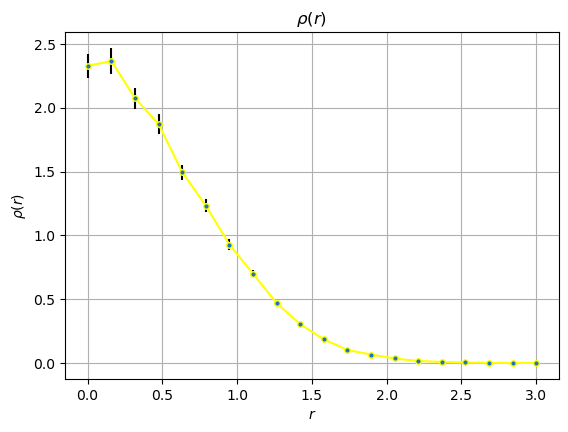

In [18]:
%matplotlib inline

n_angles = theta.size * phi.size
density_raw, error_raw = np.loadtxt("iofiles/onebodydensity.dat", delimiter=',', unpack=True)

density = density_raw.reshape(radius.size, n_angles).mean(axis=1)

# error propagation: sqrt(sum(err^2)) / n_angles
error = np.sqrt((error_raw**2).reshape(radius.size, n_angles).sum(axis=1)) / n_angles

fig = plt.figure(figsize=(14, 4.5))
gs = fig.add_gridspec(1, 2)
ax = fig.add_subplot(gs[0, 0])
ax.errorbar(radius, density, yerr=error, color='yellow', ecolor='black',
            marker='.', markersize=8, linestyle='-', mfc="tab:blue")
ax.set_title(r"$\rho(r)$")
ax.set_ylabel(r"$\rho(r)$")
ax.set_xlabel(r"$r$")